In [ ]:
# --- Project setup: portable paths (no hard-coded absolute paths) ---
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
ROOT = next(p for p in (_cwd, *_cwd.parents) if (p / "project_paths.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from project_paths import DATA_DIR, MODELS_DIR

In [2]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Metadaten laden (für das Target y)
df_meta = pd.read_csv(DATA_DIR / "perovskite_metadata_overview_reduced_EwaldM.csv")
print(df_meta.shape)

# Hocheffiziente SOAP-Features laden (für das X)
X = np.load(DATA_DIR / "perovskite_ewald_features_reduced.npy")  # Deine Feature-Matrix
print(X.shape)
print('Number of entries: ',df_meta.shape[0])
df_meta.head()


(7875, 10)
(7875, 900)
Number of entries:  7875


,entry_id,name,formula,spacegroup,crystal_structure,band_gap,is_metal,energy_above_hull,is_stable,delta_e
0,647362,CaInBr3,Br6Ca2In2,Cmcm,orthorhombic,3.243,False,0.000151,False,-1.707352
1,1377987,CaTlBr3,Br6Ca2Tl2,Cmcm,orthorhombic,3.857,False,0.000000,True,-1.794562
2,14334,CdInBr3,Br12Cd4In4,Pnma,orthorhombic,2.176,False,0.007316,False,-0.990649
3,647360,CrInBr3,Br12Cr4In4,P21/c,monoclinic,0.431,False,0.040698,False,-0.846143
4,1368552,CsAgBr3,Ag2Br6Cs2,I4/mmm,tetragonal,0.000,True,0.000000,True,-1.126859


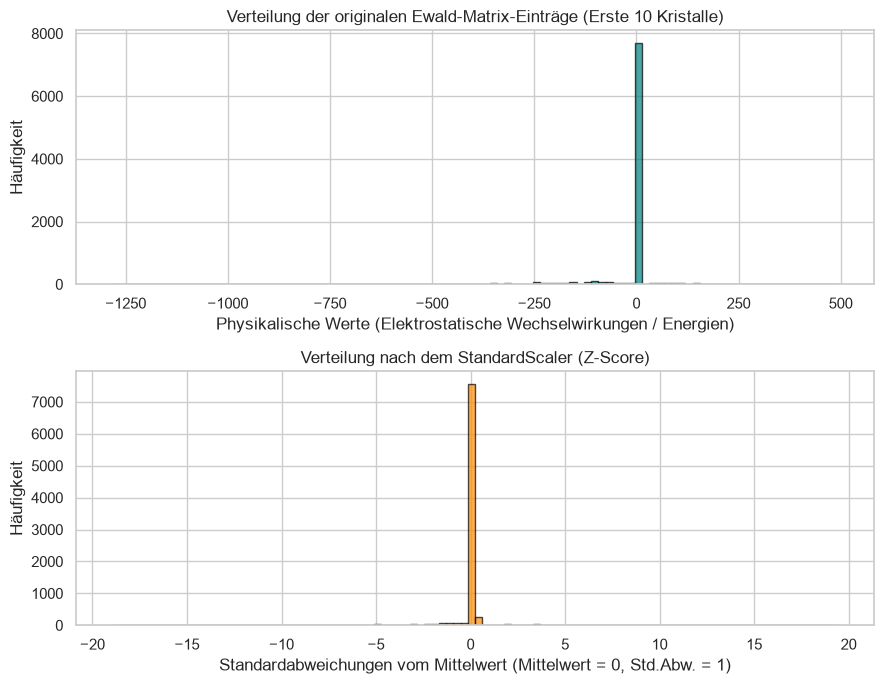

In [139]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- Simulation deiner Daten (falls du es direkt testen willst) ---
# Angenommen X sind deine flachgeklopften Ewald-Matrizen (z.B. 100 Kristalle mit je 400 Features)
# X = df_ewald_flat.values 

# 1. Normierung durchführen
scaler_X = StandardScaler()
X_ewald_normalized = scaler_X.fit_transform(X)

# 2. Plots erstellen (2 Zeilen, 1 Spalte)
fig, axs = plt.subplots(2, 1, figsize=(9, 7))

# --- OBERER PLOT: Originale Ewald-Einträge ---
# Wir nehmen die ersten 10 Kristalle und klopfen alle ihre Matrix-Einträge zu einem 1D-Vektor flach
ewald_original_flat = X[0:10].ravel()

axs[0].hist(ewald_original_flat, bins=100, color="teal", edgecolor="black", alpha=0.7)
axs[0].set_title("Verteilung der originalen Ewald-Matrix-Einträge (Erste 10 Kristalle)")
axs[0].set_xlabel("Physikalische Werte (Elektrostatische Wechselwirkungen / Energien)")
axs[0].set_ylabel("Häufigkeit")

# --- UNTERER PLOT: Standardisierte Einträge ---
# Auch hier klopfen wir die ersten 10 normierten Kristalle flach
ewald_normalized_flat = X_ewald_normalized[0:10].ravel()

axs[1].hist(ewald_normalized_flat, bins=100, color="darkorange", edgecolor="black", alpha=0.7)
axs[1].set_title("Verteilung nach dem StandardScaler (Z-Score)")
axs[1].set_xlabel("Standardabweichungen vom Mittelwert (Mittelwert = 0, Std.Abw. = 1)")
axs[1].set_ylabel("Häufigkeit")

# Layout optimieren und anzeigen
plt.tight_layout()
plt.show()

In [11]:
EaH = df_meta["energy_above_hull"].values  # Dein Target-Vektor
print('Y shape: ', EaH.shape)

stability_list = []
for E in EaH:
    if E <= 0.05:
        stability_list.append(0)  # Stable
    elif E < 0.1:                 # Korrigiert: 'elif' statt 'else if'
        stability_list.append(1)  # Metastable
    else: 
        stability_list.append(2)  # Unstabl

# Die Liste als neue Spalte zum DataFrame hinzufügen
df_meta["stability_class"] = stability_list

# Kurzer Check, ob alles geklappt hat (zeigt die ersten Zeilen)
print(df_meta[["energy_above_hull", "stability_class"]].head())

Y shape:  (7875,)
   energy_above_hull  stability_class
0           0.000151                0
1           0.000000                0
2           0.007316                0
3           0.040698                0
4           0.000000                0


/var/folders/kx/_4rxcfss2x9_kdwvm16vb0gm0000gn/T/ipykernel_55288/3956536121.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_meta, x="stability_class", palette="viridis")


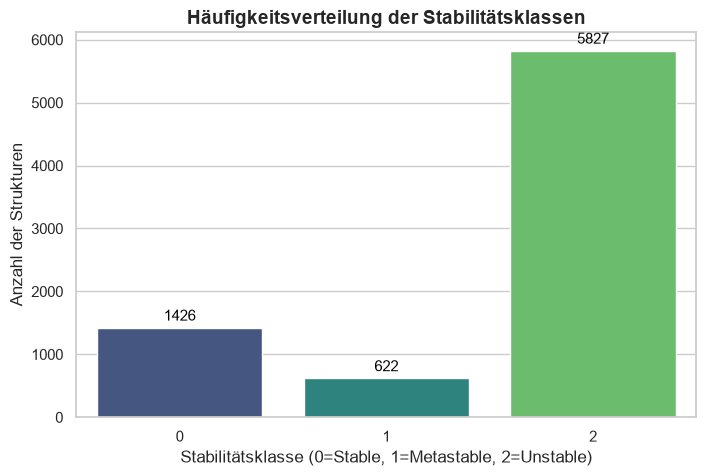

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Design-Stil festlegen (optional, sieht aber besser aus)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_meta, x="stability_class", palette="viridis")

# Titel und Beschriftungen hinzufügen
plt.title("Häufigkeitsverteilung der Stabilitätsklassen", fontsize=14, fontweight='bold')
plt.xlabel("Stabilitätsklasse (0=Stable, 1=Metastable, 2=Unstable)", fontsize=12)
plt.ylabel("Anzahl der Strukturen", fontsize=12)

# Die exakten Zahlen über die Balken schreiben
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, stability_list, test_size=0.2, random_state=42)
print("X_train Form:", X_train.shape)  # Bereit für Random Forest, Ridge Regression etc.

X_train Form: (6300, 900)


## Define MLP Model

In [91]:
class MLP(nn.Module):
    def __init__(self, hidden_dim, input_dim=900, output_dim=3):
        super(MLP, self).__init__()
        
       
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), # Input Layer to Hidden Layer
            nn.ReLU(),  # Activation function
            nn.Linear(hidden_dim, hidden_dim), # Hidden Layer to Hidden Layer
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), # Hidden Layer to Output Layer
            nn.ReLU(),  # Softmax activation for multi-class classification
            nn.Linear(hidden_dim, output_dim) # Hidden Layer to Output Layer
            #nn.Softmax()  # Softmax activation for multi-class classification
        )
        
    def forward(self, x):
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
            
        return self.network(x)

In [92]:
# --- Example Usage ---
# Let's say we use the data from your previous step (10 objects, 1 feature each = 10 inputs)
input_size = 900 
hidden_size = 10

# Instantiate the model
model = MLP(input_dim=input_size, hidden_dim=hidden_size)

# Test with a dummy batch of 4 instances
dummy_input = torch.randn(4, 900, 1) 
predictions = model(dummy_input)
print("Output-Shape:", predictions.shape)  # Erwartet: torch.Size([4, 1])

print(f"\nOutput shape: {predictions}")

Output-Shape: torch.Size([4, 3])

Output shape: tensor([[-0.1947, -0.3194,  0.1593],
        [ 0.0169, -0.5143,  0.2288],
        [-0.1397, -0.3713,  0.1482],
        [-0.0825, -0.4198,  0.1588]], grad_fn=<AddmmBackward0>)


## Define Training Loop

In [93]:
def training_loop1(model, steps=1000, learning_rate=0.001):
    loss = nn.CrossEntropyLoss()  # CrossEntropyLoss for multi-class classification
    optimizer = torch.optim.Adam(model.parameters(),lr = learning_rate)

    model.train()

    losses = []

    for step in range(steps):
        # --- MLP Forward Pass ---
        mlp_predictions = model(torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1))
        mlp_loss = loss(mlp_predictions, torch.tensor(y_train, dtype=torch.long))

        # --- Backpropagation ---
        optimizer.zero_grad()
        mlp_loss.backward()
        optimizer.step()

        losses.append(mlp_loss.item())

        if (step+1) % 100 == 0:
            print(f"Step [{step+1}/{steps}], Loss: {mlp_loss.item():.4f}")

    return model, losses


In [94]:
import test
from torch.utils.data import TensorDataset, DataLoader

def training_loop(model, X_train, y_train, epochs=50, batch_size=64, learning_rate=0.001):
    # 1. Daten in PyTorch Tensoren umwandeln und ein Dataset erstellen
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    dataset = TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    testset = TensorDataset(X_test_tensor, y_test_tensor)
    test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    model.train()
    epoch_losses = []
    test_losses = []

    # Äußere Schleife: Epochen (Durchgänge durch den kompletten Datensatz)
    for epoch in range(epochs):
        running_loss = 0.0
        model.train()
        
        # Innere Schleife: Iteration über die Mini-Batches
        for batch_X, batch_y in train_loader:
            
            # --- MLP Forward Pass ---
            # batch_X hat hier z.B. die Form [64, 900]
            predictions = model(batch_X)
            loss = loss_fn(predictions, batch_y)

            # --- Backpropagation ---
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Loss für diesen Batch aufaddieren
            running_loss += loss.item() * batch_X.size(0)

        model.eval() # Schaltet Dropout und BatchNorm in den Test-Modus
        running_test_loss = 0.0
        
        with torch.no_grad(): # Schaltet die Gradienten-Berechnung ab (spart RAM)
            for batch_X, batch_y in test_loader:
                test_predictions = model(batch_X)
                test_loss = loss_fn(test_predictions, batch_y)
                
                running_test_loss += test_loss.item() * batch_X.size(0)
                
        # Durchschnittlichen Test-Loss berechnen und speichern
        epoch_test_loss = running_test_loss / len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        # Durchschnittlichen Loss für die gesamte Epoche berechnen
        total_epoch_loss = running_loss / len(train_loader.dataset)
        epoch_losses.append(total_epoch_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_epoch_loss:.4f}")

    return model, epoch_losses, test_losses

In [104]:
model = MLP(hidden_dim=40)
model, losses, test_losses = training_loop(model, X_train, y_train, epochs=1000, batch_size=256, learning_rate=0.001)

Epoch [1/1000], Loss: 0.8484
Epoch [5/1000], Loss: 0.6225
Epoch [10/1000], Loss: 0.5667
Epoch [15/1000], Loss: 0.5335
Epoch [20/1000], Loss: 0.5025
Epoch [25/1000], Loss: 0.4786
Epoch [30/1000], Loss: 0.4412
Epoch [35/1000], Loss: 0.4481
Epoch [40/1000], Loss: 0.4197
Epoch [45/1000], Loss: 0.4182
Epoch [50/1000], Loss: 0.4015
Epoch [55/1000], Loss: 0.3931
Epoch [60/1000], Loss: 0.4070
Epoch [65/1000], Loss: 0.3903
Epoch [70/1000], Loss: 0.3640
Epoch [75/1000], Loss: 0.3752
Epoch [80/1000], Loss: 0.3669
Epoch [85/1000], Loss: 0.3572
Epoch [90/1000], Loss: 0.3510
Epoch [95/1000], Loss: 0.3452
Epoch [100/1000], Loss: 0.5179
Epoch [105/1000], Loss: 0.3679
Epoch [110/1000], Loss: 0.3438
Epoch [115/1000], Loss: 0.3325
Epoch [120/1000], Loss: 0.3323
Epoch [125/1000], Loss: 0.3226
Epoch [130/1000], Loss: 0.3260
Epoch [135/1000], Loss: 0.3156
Epoch [140/1000], Loss: 0.3165
Epoch [145/1000], Loss: 0.3208
Epoch [150/1000], Loss: 0.3122
Epoch [155/1000], Loss: 0.3010
Epoch [160/1000], Loss: 0.2992

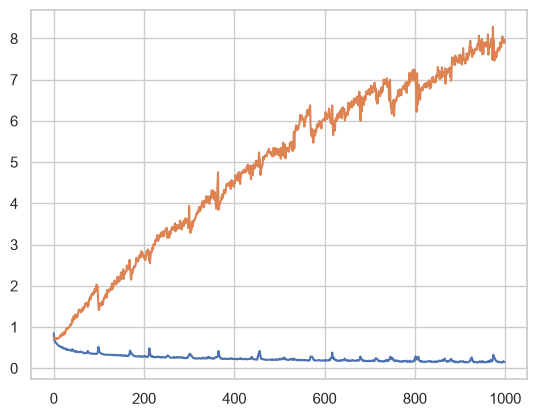

In [108]:
plt.plot(losses)
plt.plot(test_losses)

## Try to improve with class weighted parameter

In [109]:
import torch
import numpy as np

# 1. Anzahl der Instanzen pro Klasse
counts = np.array([1400, 600, 5800])
total = counts.sum()

# 2. Berechne die Gewichte (invers zur Häufigkeit)
# Formel: total / (num_classes * count)
class_weights = total / (3.0 * counts)

# Umwandeln in einen PyTorch-Tensor (muss denselben Datentyp wie die Predictions haben)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Berechnete Klassengewichte:", class_weights)
# Ergibt ca.: [1.85, 4.33, 0.44] -> Metastabil wird fast 10x so stark gewichtet wie instabil!

Berechnete Klassengewichte: [1.85714286 4.33333333 0.44827586]


In [129]:
import test
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


def weighted_training_loop(
    model,
    X_train,
    y_train,
    class_weights_tensor = class_weights_tensor,
    epochs=50,
    batch_size=64,
    learning_rate=0.001,
):
    # 1. Daten in PyTorch Tensoren umwandeln und ein Dataset erstellen
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    testset = TensorDataset(X_test_tensor, y_test_tensor)
    test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

    # Hier werden die class_weights an die Loss-Funktion übergeben
    loss_fn = nn.CrossEntropyLoss(
        weight=class_weights_tensor.to(X_tensor.device)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    model.train()
    epoch_losses = []
    test_losses = []

    # Äußere Schleife: Epochen (Durchgänge durch den kompletten Datensatz)
    for epoch in range(epochs):
        running_loss = 0.0
        model.train()

        # Innere Schleife: Iteration über die Mini-Batches
        for batch_X, batch_y in train_loader:

            # --- MLP Forward Pass ---
            predictions = model(batch_X)
            loss = loss_fn(predictions, batch_y)

            # --- Backpropagation ---
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Loss für diesen Batch aufaddieren
            running_loss += loss.item() * batch_X.size(0)

        model.eval()  # Schaltet Dropout und BatchNorm in den Test-Modus
        running_test_loss = 0.0

        with torch.no_grad():  # Schaltet die Gradienten-Berechnung ab (spart RAM)
            for batch_X, batch_y in test_loader:
                test_predictions = model(batch_X)
                test_loss = loss_fn(test_predictions, batch_y)

                running_test_loss += test_loss.item() * batch_X.size(0)

        # Durchschnittlichen Test-Loss berechnen und speichern
        epoch_test_loss = running_test_loss / len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        # Durchschnittlichen Loss für die gesamte Epoche berechnen
        total_epoch_loss = running_loss / len(train_loader.dataset)
        epoch_losses.append(total_epoch_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_epoch_loss:.4f}")

    return model, epoch_losses, test_losses

Epoch [1/200], Loss: 1.0932
Epoch [5/200], Loss: 0.9484
Epoch [10/200], Loss: 0.8850
Epoch [15/200], Loss: 0.8477
Epoch [20/200], Loss: 0.8103
Epoch [25/200], Loss: 0.8176
Epoch [30/200], Loss: 0.7698
Epoch [35/200], Loss: 0.7427
Epoch [40/200], Loss: 0.7290
Epoch [45/200], Loss: 0.7101
Epoch [50/200], Loss: 0.7486
Epoch [55/200], Loss: 0.6911
Epoch [60/200], Loss: 0.6812
Epoch [65/200], Loss: 0.7775
Epoch [70/200], Loss: 0.7048
Epoch [75/200], Loss: 0.6138
Epoch [80/200], Loss: 0.6081
Epoch [85/200], Loss: 0.6091
Epoch [90/200], Loss: 0.6006
Epoch [95/200], Loss: 0.5887
Epoch [100/200], Loss: 0.5974
Epoch [105/200], Loss: 0.5653
Epoch [110/200], Loss: 0.5515
Epoch [115/200], Loss: 0.5568
Epoch [120/200], Loss: 0.5334
Epoch [125/200], Loss: 0.5626
Epoch [130/200], Loss: 0.6519
Epoch [135/200], Loss: 0.5216
Epoch [140/200], Loss: 0.5057
Epoch [145/200], Loss: 0.5148
Epoch [150/200], Loss: 0.5754
Epoch [155/200], Loss: 0.5577
Epoch [160/200], Loss: 0.5245
Epoch [165/200], Loss: 0.4991
Ep

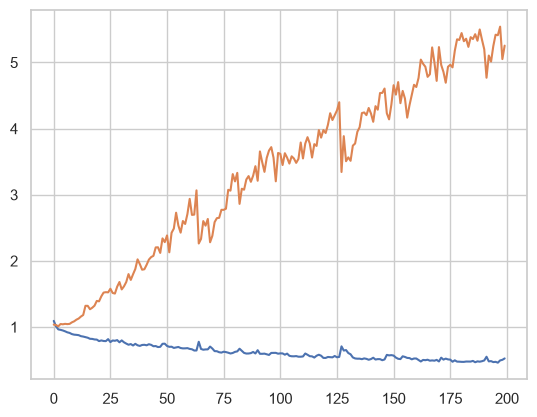

In [135]:
model = MLP(hidden_dim=40)
model, losses, test_losses = weighted_training_loop(model, X_train, y_train, epochs=200, batch_size=64, learning_rate=0.001)
plt.plot(losses)
plt.plot(test_losses)

## Change of plan: Try RF Classifier on Stability Classes

In [100]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model,x_test, y_test):

    y_pred = model.predict(x_test)

    # 1. Die Confusion Matrix normalisieren ('true' normiert über die tatsächliche Achse)
    cm_percentage = confusion_matrix(y_test, y_pred, normalize="true")

    # 2. Beschriftungen für die Achsen definieren
    #labels_y = ["Kein Metall\n(Negativ)", "Metall\n(Positiv)"]
    #labels_x = ["Kein Metall\n(False)", "Metall\n(True)"]

    # 3. Den Plot erstellen
    plt.figure(figsize=(6, 5))

    # sns.heatmap zeichnet die Matrix
    sns.heatmap(
        cm_percentage,
        annot=True,  # Schreibt die Werte in die Quadrate
        fmt=".1%",  # <--- WICHTIG: Formatiert die Zahlen als Prozent mit einer Nachkommastelle (z.B. 94.5%)
        cmap="Blues",  # Blaue Farbpalette
        cbar=True,
        square=True,
        vmin=0,
        vmax=1,  # Setzt die Farbskala fest von 0% bis 100%
    )

    # 4. Titel und Achsenbeschriftungen
    plt.title(
        "Confusion Matrix (Prozentual) - Metall-Klassifikation",
        fontsize=14,
        pad=20,
    )
    plt.xlabel("Vorhersage des Modells (Predicted)", fontsize=12)
    plt.ylabel("Tatsächliche Struktur (Actual)", fontsize=12)

    # Grafik anzeigen
    plt.tight_layout()
    plt.show()

In [101]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Das Basis-Modell definieren
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

# 2. Den Suchraum (Grid) festlegen
# Tipp: Halte die Liste kurz, da jede Kombination mit jeder multipliziert wird!
param_grid = {
    "n_estimators": [50, 100, 200],  # Anzahl der Bäume
    "max_depth": [5, 10, None],  # Tiefe der Bäume (None bedeutet unbegrenzt)
    "min_samples_split": [2, 5, 10],  # Mindestanzahl an Strukturen für einen Split
}

# 3. Grid Search initialisieren
# cv=3 bedeutet 3-fache Kreuzvalidierung. scoring='f1_macro' ist extrem wichtig,
# damit das Modell für beide Klassen (Metall & Nicht-Metall) optimiert wird, trotz Bias!
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=2,  # Zeigt dir den Fortschritt live an
    n_jobs=-1,  # Nutzt alle CPU-Kerne parallel
)

# 4. Suche starten
print("Starte Grid Search über alle Parameter-Kombinationen...")
grid_search.fit(X_train, y_train)

# 5. Bestes Ergebnis anzeigen
print("\n=== GRID SEARCH BEENDET ===")
print(f"Bester F1-Macro-Score: {grid_search.best_score_:.2f}")
print("Beste Parameter-Kombination:")
print(grid_search.best_params_)

# Das beste Modell direkt für Vorhersagen nutzen
best_rf_model = grid_search.best_estimator_

Starte Grid Search über alle Parameter-Kombinationen...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.5s
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.5s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.3s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.3s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.3s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=

In [102]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_rf_model.predict(X_test)

# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
print(
    classification_report(
        y_test, y_pred
    ))

Model Accuracy: 0.81

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.73      0.67       306
           1       0.36      0.32      0.34       127
           2       0.92      0.89      0.90      1142

    accuracy                           0.81      1575
   macro avg       0.63      0.64      0.64      1575
weighted avg       0.82      0.81      0.81      1575



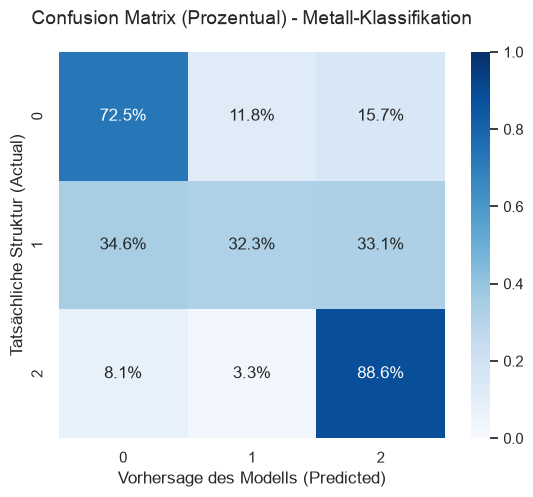

In [103]:
plot_confusion_matrix(best_rf_model, X_test, y_test)


## Try 1-D Convolution + smaller MLP

In [143]:
import torch
import torch.nn as nn

class Ewald2DCNN(nn.Module):
    def __init__(self, output_dim=1, dropout_rate=0.3):
        super(Ewald2DCNN, self).__init__()
        
        # 2D-CNN Block für die 30x30 Matrix
        self.conv_block = nn.Sequential(
            # 1. Block: Input (Batch, 1, 30, 30) -> Output (Batch, 16, 30, 30)
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # Reduziert Dimension von 30x30 auf 15x15
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 2. Block: Output (Batch, 32, 15, 15)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Reduziert Dimension von 15x15 auf 7x7 (durch Abrundung bei ungeraden Zahlen)
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Nach den beiden Pooling-Schichten ist die Matrix noch 7x7 groß.
        # Flatten-Dimension = Kanäle (32) * Höhe (7) * Breite (7) = 1568
        self.flatten_dim = 32 * 7 * 7
        
        # Dichter MLP-Block für die Vorhersage
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flatten_dim, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            
            nn.Linear(128, 32),
            nn.ReLU(),
            
            nn.Linear(32, output_dim)
        )
        
    def forward(self, x):
        # x kommt an als: (Batch_Size, 900)
        # Wir wandeln es um in: (Batch_Size, 1, 30, 30)
        # Die -1 sagt PyTorch, dass die Batch-Größe dynamisch beibehalten werden soll.
        x = x.view(-1, 1, 30, 30)
        # x hat initial die Form (Batch_Size, 30, 30)
        # Wir fügen die Channel-Dimension (1 Kanal, da Graustufen-artig) hinzu
        if len(x.shape) == 3:
            x = x.unsqueeze(1) # -> (Batch_Size, 1, 30, 30)
            
        x = self.conv_block(x)
        x = self.mlp(x)
        return x

# --- Testlauf ---
if __name__ == "__main__":
    # Simuliere 8 Kristalle mit einer 30x30 Ewald-Matrix
    sample_input = torch.randn(8, 30, 30)
    
    model = Ewald2DCNN(output_dim=1)
    output = model(sample_input)
    
    print(f"Input Shape:  {sample_input.shape}")
    print(f"Output Shape: {output.shape}") # (8, 1)

Input Shape:  torch.Size([8, 30, 30])
Output Shape: torch.Size([8, 1])


In [145]:
cnn_model = Ewald2DCNN(output_dim=3)
cnn_model, losses, test_losses = training_loop(cnn_model, X_train, y_train, epochs=100, batch_size=256, learning_rate=0.001)


Epoch [1/100], Loss: 0.7545
Epoch [5/100], Loss: 0.6056
Epoch [10/100], Loss: 0.5804
Epoch [15/100], Loss: 0.5540
Epoch [20/100], Loss: 0.5330
Epoch [25/100], Loss: 0.5048
Epoch [30/100], Loss: 0.4950
Epoch [35/100], Loss: 0.4786
Epoch [40/100], Loss: 0.4725
Epoch [45/100], Loss: 0.4558
Epoch [50/100], Loss: 0.4428
Epoch [55/100], Loss: 0.4288
Epoch [60/100], Loss: 0.3990
Epoch [65/100], Loss: 0.3988
Epoch [70/100], Loss: 0.4056
Epoch [75/100], Loss: 0.3842
Epoch [80/100], Loss: 0.3830
Epoch [85/100], Loss: 0.3612
Epoch [90/100], Loss: 0.3555
Epoch [95/100], Loss: 0.4024
Epoch [100/100], Loss: 0.3374


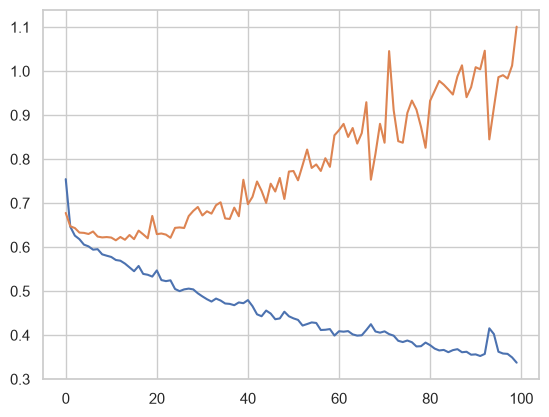

In [147]:
plt.plot(losses)
plt.plot(test_losses
)

In [148]:
from torchsummary import summary

# Wichtig: Das Modell muss auf dem richtigen Device sein (z.B. "cpu" oder "cuda")
device = "cuda" if torch.cuda.is_available() else "cpu"
cnn_model = cnn_model.to(device)

# summary(modell, input_size=(Kanäle, Höhe, Breite))
# Bei deiner Ewald-Matrix ist das (1, 30, 30)
summary(cnn_model, input_size=(1, 30, 30), device=device)

ModuleNotFoundError: No module named 'torchsummary'